## **Laboratorio Clase 2: LLMs Multimodales y en Produccion**

Exploramos los LLMs mas alla del texto: analisis de imagenes, generacion visual, pipelines de extraccion de datos y buenas practicas de produccion.

### Que practicaras

- Analizar imagenes con GPT-4o Vision (descripcion, extraccion estructurada)
- Generar imagenes con gpt-image-1
- Construir pipelines de extraccion de datos estructurados con pandas
- Estimar costes y aplicar patrones de produccion (retry, templates)
- Usar un LLM para Text-to-SQL (lenguaje natural a consultas SQL)

### Objetivos

Al finalizar seras capaz de:

- Enviar imagenes a un LLM y extraer informacion estructurada
- Generar imagenes a partir de texto con gpt-image-1
- Construir pipelines LLM robustos con manejo de errores y estimacion de costes
- Aplicar LLMs a tareas de Data Science: extraccion de datos y Text-to-SQL

## Seccion 1: Configuracion del entorno


In [1]:
!pip install --upgrade openai tiktoken requests matplotlib
import json, re, sqlite3, time, io, base64
import pandas as pd
import matplotlib.pyplot as plt

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 3.27.0 requires ffmpy, which is not installed.
gradio 3.27.0 requires pydub, which is not installed.
so-vits-svc-fork 3.10.3 requires pydub, which is not installed.
so-vits-svc-fork 3.10.3 requires pysimplegui>=4.6, which is not installed.
so-vits-svc-fork 3.10.3 requires fastapi==0.88, but you have fastapi 0.104.1 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached matplotlib-3.9.4-cp39-cp39-win_amd64.whl.metadata (11 kB)
Using cached matplotlib-3.9.4-cp39-cp39-win_amd64.whl (7.8 MB)
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.8.2
    Uninstalling matplotlib-3.8.2:
      Successfully uninstalled matplotlib-3.8.2


In [7]:
import requests, base64
from openai import OpenAI

OPENAI_API_KEY = "sk-..."  # Reemplaza con tu clave
client = OpenAI(api_key=OPENAI_API_KEY)

def preguntar(pregunta, temperatura=0.0, max_tokens=300):
    r = client.responses.create(model="gpt-4o-mini", input=pregunta,
                                 temperature=temperatura, max_output_tokens=max_tokens)
    return r.output_text

def cargar_imagen(url):
    resp = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}, timeout=15)
    resp.raise_for_status()
    content_type = resp.headers.get("content-type", "image/jpeg").split(";")[0]
    b64 = base64.standard_b64encode(resp.content).decode("utf-8")
    return f"data:{content_type};base64,{b64}"

print("Cliente listo.")

Cliente listo.


## Seccion 2: Vision — Analizando Imagenes con GPT-4o


Los modelos multimodales procesan texto e imagen en el mismo prompt. El input incluye ambos tipos de contenido: `input_text` e `input_image`.

**Celda 3: Descripcion basica de una imagen**

In [23]:
from IPython.display import Image, display

url = 'https://image-cdn-ak.spotifycdn.com/image/ab67706c0000da84796ba035efe74d38bd970d74'
img = cargar_imagen(url)
display(Image(url=url, width=400))

r = client.responses.create(
    model='gpt-4o-mini',
    input=[{
        'role': 'user',
        'content': [
            {'type': 'input_text',  'text': 'Describe esta imagen en detalle: que ves, colores, contexto, que tipo de contenido es.'},
            {'type': 'input_image', 'image_url': img}
        ]
    }]
)
print(r.output_text)

La imagen muestra a un hombre vestido con un traje oscuro, sosteniendo un vaso con lo que parece ser una bebida, probablemente whisky. Él está en un ambiente que parece un bar o una taberna, dado el fondo con estanterías llenas de botellas. 

Los colores predominantes son oscuros, como el marrón y el negro del entorno, junto con el gris del traje del hombre. Su camisa es de un tono claro, lo que crea un contraste con el traje.

El contexto podría sugerir un momento de celebración o brindis, ya que el hombre levanta su vaso, mirando a su alrededor, lo que puede indicar que está dirigiéndose a un grupo. Este tipo de contenido podría pertenecer a una serie de televisión, dado el estilo y la composición de la imagen. 

La escena evoca una atmósfera social y festiva.


La entrada tiene dos tipos de contenido: `input_text` (texto) e `input_image` (URL). El modelo los procesa juntos — no es un pipeline de dos pasos. GPT-4o-mini es economico; para analisis complejos usa `gpt-4o`.

**Celda 4: Extraccion estructurada de datos de una imagen**


In [24]:
url_perro = requests.get('https://dog.ceo/api/breeds/image/random').json()['message']
print(f'Imagen: {url_perro}')
img_perro = cargar_imagen(url_perro)
display(Image(url=url_perro, width=400))

prompt_ext = (
    'Analiza esta imagen de un animal y devuelve SOLO JSON puro (sin markdown):\n'
    '{"especie": "...", "raza_estimada": "...", "color_pelo": "...",'
    ' "tamano_estimado": "pequeno/mediano/grande", "entorno": "interior/exterior/desconocido",'
    ' "confianza": 0.0}'
)

r = client.responses.create(
    model='gpt-4o-mini',
    input=[{
        'role': 'user',
        'content': [
            {'type': 'input_text',  'text': prompt_ext},
            {'type': 'input_image', 'image_url': img_perro}
        ]
    }],
    temperature=0.0
)

texto = re.sub(r'^```(?:json)?\s*\n?', '', r.output_text.strip())
texto = re.sub(r'\n?```\s*$', '', texto).strip()
datos = json.loads(texto)
for k, v in datos.items():
    print(f'  {k}: {v}')

Imagen: https://images.dog.ceo/breeds/terrier-australian/n02096294_6450.jpg


  especie: perro
  raza_estimada: Yorkshire Terrier
  color_pelo: marrón claro
  tamano_estimado: pequeño
  entorno: exterior
  confianza: 0.0


Vision + JSON es muy potente para automatizar catalogacion de imagenes. Casos de uso reales: inventario de productos con fotos, extraccion de datos de recibos/facturas, analisis de imagenes medicas para preprocesamiento.

**Celda 5: Analisis de una infografia — leer texto en imagen**


In [25]:
r = client.responses.create(
    model='gpt-4o-mini',
    input=[{
        'role': 'user',
        'content': [
            {'type': 'input_text',  'text': 'Compara estas dos imagenes. Describe brevemente cada una y explica en que se diferencian (tipo de contenido, contexto, uso).'},
            {'type': 'input_image', 'image_url': img},
            {'type': 'input_image', 'image_url': img_perro}
        ]
    }]
)
print(r.output_text)

**Descripción de las imágenes:**

1. **Primera Imagen:**
   - **Contenido:** Un hombre en traje, sosteniendo un vaso de whisky.
   - **Contexto:** La escena parece estar ambientada en un bar o una sala social. La expresión y el gesto del hombre sugieren que está brindando o celebrando algo.
   - **Uso:** Esta imagen puede ser utilizada en contextos relacionados con celebraciones, eventos sociales o para ilustrar momentos de camaradería.

2. **Segunda Imagen:**
   - **Contenido:** Un perro de pelaje desaliñado, con orejas puntiagudas y una mirada curiosa.
   - **Contexto:** La imagen muestra al perro en un entorno exterior, lo que podría indicar que está paseando o disfrutando de su tiempo al aire libre.
   - **Uso:** Esta imagen es adecuada para temas de mascotas, amor por los animales, o felicidad y diversión en la compañía de un perro.

**Diferencias:**

- **Tipo de contenido:** La primera imagen se centra en un ser humano y una situación social, mientras que la segunda imagen presen

Se pueden enviar multiples imagenes en el mismo prompt. Esto permite comparacion de imagenes, analisis de cambios (antes/despues), revision de documentos con varias paginas, etc. Nota: cuantas mas imagenes, mas tokens de entrada y mayor coste.

## Seccion 3: Generacion de Imagenes con gpt-image-1


gpt-image-1 es el modelo actual de OpenAI para generacion de imagenes a partir de texto. Conecta con las diapositivas de generacion de imagenes (el animal fantastico estilo Da Vinci).

**Celda 6: Generar una imagen**

Prompt: Un robot transparente de cristal sentado en una biblioteca moderna, rodeado de libros flotantes y circuitos de luz azul, estilo ilustracion tecnica detallada, fondo blanco


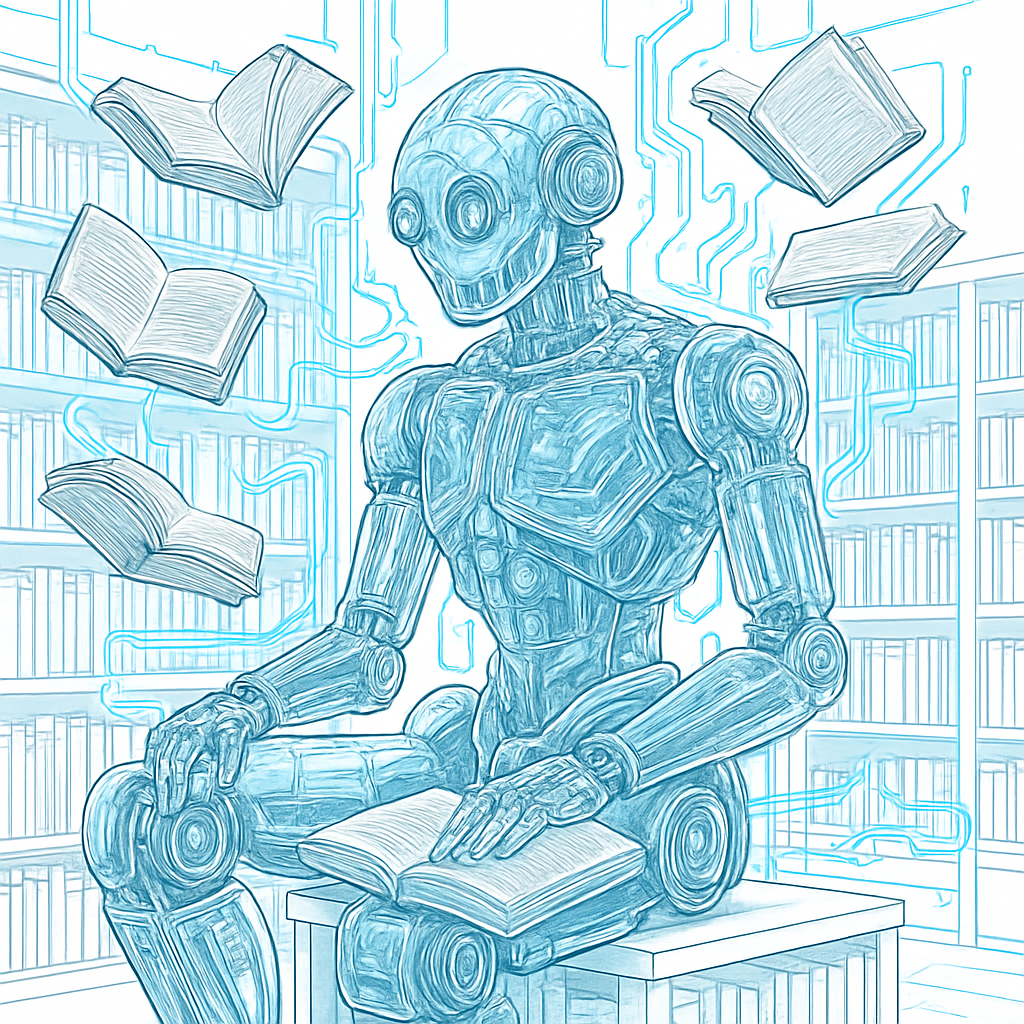

In [20]:
from IPython.display import Image as IPImage, display
import base64

prompt_imagen = (
    'Un robot transparente de cristal sentado en una biblioteca moderna, '
    'rodeado de libros flotantes y circuitos de luz azul, '
    'estilo ilustracion tecnica detallada, fondo blanco'
)

respuesta_img = client.images.generate(
    model='gpt-image-1',
    prompt=prompt_imagen,
    size='1024x1024',
    quality='medium',
    n=1
)

img_bytes = base64.b64decode(respuesta_img.data[0].b64_json)
print(f'Prompt: {prompt_imagen}')
display(IPImage(data=img_bytes, width=512))

gpt-image-1 devuelve la imagen como base64 — no hay URL que expire. Para produccion, decodificar con `base64.b64decode()` y guardar en almacenamiento propio.

**Celda 7: El mismo concepto en distintos estilos**


In [12]:
concepto = 'un grafo de conocimiento con nodos y aristas, representando conexiones entre conceptos de IA'

estilos = [
    ('minimalista', f'{concepto}, flat design minimalista, colores azul y blanco'),
    ('futurista',   f'{concepto}, estilo sci-fi, luces neon sobre fondo oscuro'),
]

for nombre, prompt_estilo in estilos:
    r = client.images.generate(model='gpt-image-1', prompt=prompt_estilo,
                               size='1024x1024', quality='medium', n=1)
    img_bytes = base64.b64decode(r.data[0].b64_json)
    print(f'Estilo: {nombre}')
    display(IPImage(data=img_bytes, width=400))
    print()

BadRequestError: Error code: 400 - {'error': {'message': "The model 'dall-e-3' does not exist.", 'type': 'image_generation_user_error', 'param': 'model', 'code': 'invalid_value'}}

El mismo concepto produce resultados muy diferentes segun el estilo del prompt. Esta tecnica de 'estilo como parametro' es fundamental: diseno de marca, mockups de UI, visualizaciones.

## Seccion 4: Salida Estructurada para Data Science


Extraer datos estructurados de texto no estructurado es uno de los casos mas valiosos en Data Science.

**Celda 8: Extraer campos de una oferta de trabajo**

In [13]:
oferta = """
Data Scientist — Startup FinTech — Madrid (hibrido)
Buscamos Data Scientist con 3-5 anos de experiencia para modelado predictivo y analisis de riesgo crediticio.
Requisitos: Python, SQL, scikit-learn. Valorable: fraud detection. Salario: 55.000-70.000 EUR/ano.
Beneficios: seguro medico, stock options, 23 dias vacaciones.
"""

prompt_ext = (
    'Extrae los datos de esta oferta en JSON puro (sin bloques de codigo markdown):\n'
    '{"cargo": "...", "empresa_tipo": "startup/pyme/corporacion", "ciudad": "...", '
    '"modalidad": "presencial/hibrido/remoto", "anos_min": num, "anos_max": num, '
    '"skills_req": [lista], "skills_val": [lista], "salario_min": num_o_null, "salario_max": num_o_null}\n\n'
    f'Oferta:\n{oferta}'
)

r = client.responses.create(model='gpt-4o-mini', input=prompt_ext, temperature=0.0)
texto = re.sub(r'^```(?:json)?\s*\n?', '', r.output_text.strip())
texto = re.sub(r'\n?```\s*$', '', texto).strip()
datos = json.loads(texto)
print(json.dumps(datos, indent=2, ensure_ascii=False))

{
  "cargo": "Data Scientist",
  "empresa_tipo": "startup",
  "ciudad": "Madrid",
  "modalidad": "hibrido",
  "anos_min": 3,
  "anos_max": 5,
  "skills_req": [
    "Python",
    "SQL",
    "scikit-learn"
  ],
  "skills_val": [
    "fraud detection"
  ],
  "salario_min": 55000,
  "salario_max": 70000
}


Este patron es la base de pipelines de enriquecimiento de datos: transformar texto no estructurado (PDFs, emails, webs) en DataFrames analizables.

**Celda 9: Pipeline batch — multiples ofertas a DataFrame**


In [ ]:
ofertas = [
    'Senior ML Engineer — Banco Santander — Madrid (presencial). 6+ anos. Python, TensorFlow, AWS SageMaker. Salario 75k-95k EUR.',
    'Junior Data Analyst — eCommerce startup — Barcelona (remoto). 1-2 anos. SQL, Power BI. Valorable Python. Salario 28k-35k EUR.',
    'AI Research Scientist — Universidad Autonoma — Madrid (presencial). 4-6 anos. PyTorch, NLP, publicaciones. Salario 50k-65k EUR.',
    'Product Data Manager — Consultora KPMG — Sevilla (hibrido). 3-4 anos. SQL, Tableau, comunicacion. Salario 40k-55k EUR.'
]

resultados = []
for i, oferta in enumerate(ofertas, 1):
    print(f'Procesando oferta {i}/{len(ofertas)}...')
    prompt = (
        'JSON puro (sin markdown): cargo, empresa_tipo(startup/pyme/corporacion/academia), ciudad, '
        'modalidad(presencial/hibrido/remoto), anos_min, anos_max, salario_min, salario_max.\n'
        f'Oferta: {oferta}'
    )
    r = client.responses.create(model='gpt-4o-mini', input=prompt, temperature=0.0)
    texto = re.sub(r'^```(?:json)?\s*\n?', '', r.output_text.strip())
    texto = re.sub(r'\n?```\s*$', '', texto).strip()
    try:
        d = json.loads(texto)
        d['oferta_original'] = oferta[:60] + '...'
        resultados.append(d)
    except Exception as e:
        print(f'  Error: {e}')

df = pd.DataFrame(resultados)
print()
df

Con el DataFrame podemos analizar: ¿cuantos puestos son remotos? ¿salario medio por tipo de empresa? ¿que skills aparecen mas? Los LLMs convierten contenido no estructurado en datos analizables con pandas.

## Seccion 5: Buenas Practicas en Produccion


**Celda 10: Estimar costes antes de lanzar un pipeline**


In [14]:
import tiktoken
enc = tiktoken.encoding_for_model('gpt-4o-mini')

# Precios gpt-4o-mini (referencia Mayo 2025 — verificar en platform.openai.com)
PRECIO_INPUT  = 0.150 / 1_000_000   # USD por token de entrada
PRECIO_OUTPUT = 0.600 / 1_000_000   # USD por token de salida

def estimar_coste(prompt_template, n_items, tokens_output=100):
    tok_prompt = len(enc.encode(prompt_template))
    total_in   = tok_prompt * n_items
    total_out  = tokens_output * n_items
    coste = total_in * PRECIO_INPUT + total_out * PRECIO_OUTPUT
    print(f'Por item:     {tok_prompt} tokens input + {tokens_output} tokens output')
    print(f'Para {n_items:,} items: {total_in:,} tokens in + {total_out:,} tokens out')
    print(f'Coste total:  ${coste:.4f} USD')
    return coste

print('=== Clasificacion de tickets de soporte (10.000 items) ===')
prompt_ticket = 'Clasifica en: tecnico/facturacion/envio/otro. Solo la categoria.\nTicket: {descripcion}'
estimar_coste(prompt_ticket, n_items=10_000, tokens_output=5)

print()
print('=== Extraccion estructurada de emails (50.000 items) ===')
prompt_email = 'JSON: asunto, urgencia(1-5), requiere_respuesta(bool). Email: {email}'
estimar_coste(prompt_email, n_items=50_000, tokens_output=30)

=== Clasificacion de tickets de soporte (10.000 items) ===
Por item:     22 tokens input + 5 tokens output
Para 10,000 items: 220,000 tokens in + 50,000 tokens out
Coste total:  $0.0630 USD

=== Extraccion estructurada de emails (50.000 items) ===
Por item:     21 tokens input + 30 tokens output
Para 50,000 items: 1,050,000 tokens in + 1,500,000 tokens out
Coste total:  $1.0575 USD


1.0574999999999999

Estimar costes **antes** de ejecutar es esencial en produccion. Herramienta: `tiktoken` para contar tokens. Los precios actualizados estan en platform.openai.com/pricing.

**Celda 11: Manejo de errores y reintentos con backoff exponencial**


In [15]:
from openai import RateLimitError, APIError

def llamar_api_robusto(prompt, max_reintentos=3, espera_base=2):
    for intento in range(1, max_reintentos + 1):
        try:
            r = client.responses.create(model='gpt-4o-mini', input=prompt, temperature=0.0)
            return r.output_text
        except RateLimitError:
            espera = espera_base * (2 ** (intento - 1))  # backoff: 2s, 4s, 8s...
            print(f'Rate limit. Intento {intento}/{max_reintentos}. Esperando {espera}s...')
            if intento == max_reintentos:
                raise
            time.sleep(espera)
        except APIError as e:
            print(f'Error API (intento {intento}): {e}')
            if intento == max_reintentos:
                raise
            time.sleep(espera_base)

# Probar con una llamada normal
resultado = llamar_api_robusto('¿Cual es la capital de Japon? Solo el nombre.')
print(f'Resultado: {resultado}')

Resultado: Tokio.


El **backoff exponencial** (esperar 2s, 4s, 8s...) es el patron estandar para manejar rate limits. Errores mas comunes: `RateLimitError` (demasiadas llamadas), `APIError` (error de servidor).

**Celda 12: Plantillas de prompts reutilizables**


In [16]:
def prompt_clasificacion(texto, categorias):
    cats = ', '.join(categorias)
    return f'Clasifica en una de estas categorias: {cats}. Solo la categoria.\n\nTexto: {texto}'

def prompt_resumen(texto, palabras_max=50, publico='general'):
    return f'Resume en maximo {palabras_max} palabras para un publico {publico}.\n\nTexto: {texto}'

def prompt_extraccion(texto, campos):
    campos_json = ', '.join([f'"{c}": "..."' for c in campos])
    return f'Extrae en JSON puro: {{{campos_json}}}\n\nTexto: {texto}'

noticia_test = 'Apple reporto ingresos de 94.9 billion dolares en Q1 2025, superando expectativas en un 3%.'

print('=== CLASIFICACION ===')
print(preguntar(prompt_clasificacion(noticia_test, ['tecnologia', 'finanzas', 'politica'])))

print('\n=== RESUMEN para analista financiero ===')
print(preguntar(prompt_resumen(noticia_test, palabras_max=20, publico='analista financiero')))

print('\n=== EXTRACCION ===')
print(preguntar(prompt_extraccion(noticia_test, ['empresa', 'ingresos_billones', 'periodo', 'resultado'])))

=== CLASIFICACION ===
Tecnología.

=== RESUMEN para analista financiero ===
Apple reportó ingresos de $94.9 mil millones en Q1 2025, superando expectativas en un 3%. Resultados positivos para analistas.

=== EXTRACCION ===
```json
{
  "empresa": "Apple",
  "ingresos_billones": "94.9",
  "periodo": "Q1 2025",
  "resultado": "superando expectativas en un 3%"
}
```


Las plantillas son el equivalente a funciones en programacion: evitan repeticion y facilitan mantenimiento. En proyectos reales se gestionan en ficheros `.py` o `.yaml` con versionado.

## Seccion 6: LLMs en Data Science — Text-to-SQL


**Text-to-SQL** convierte preguntas en lenguaje natural a SQL. Es el ejercicio de la asignatura directamente conectado con la diapositiva 'LLMs en Data Science'.

**Celda 13: Preparar base de datos SQLite**

In [17]:
import sqlite3, pandas as pd

conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

cursor.executescript("""
CREATE TABLE productos (
    id INTEGER PRIMARY KEY, nombre TEXT, categoria TEXT, precio REAL, stock INTEGER
);
CREATE TABLE ventas (
    id INTEGER PRIMARY KEY, producto_id INTEGER, fecha TEXT,
    cantidad INTEGER, canal TEXT,
    FOREIGN KEY (producto_id) REFERENCES productos(id)
);
INSERT INTO productos VALUES
    (1,'MacBook Pro M4','ordenadores',2499.99,45),
    (2,'iPhone 16 Pro','moviles',1199.99,120),
    (3,'iPad Air','tablets',749.99,78),
    (4,'AirPods Pro','audio',279.99,200),
    (5,'Apple Watch','wearables',399.99,95);
INSERT INTO ventas VALUES
    (1,1,'2025-01-10',3,'online'),(2,2,'2025-01-11',8,'tienda'),
    (3,2,'2025-01-12',5,'online'),(4,4,'2025-01-13',15,'online'),
    (5,3,'2025-01-14',4,'tienda'),(6,1,'2025-01-15',2,'online'),
    (7,5,'2025-01-16',6,'tienda'),(8,2,'2025-01-17',10,'online'),
    (9,4,'2025-01-18',20,'tienda'),(10,3,'2025-01-19',3,'online');
""")
conn.commit()
print('Base de datos lista.')
print(pd.read_sql('SELECT * FROM productos', conn))

Base de datos lista.
   id          nombre    categoria   precio  stock
0   1  MacBook Pro M4  ordenadores  2499.99     45
1   2   iPhone 16 Pro      moviles  1199.99    120
2   3        iPad Air      tablets   749.99     78
3   4     AirPods Pro        audio   279.99    200
4   5     Apple Watch    wearables   399.99     95


Dos tablas: `productos` (catalogo con precios y stock) y `ventas` (historial de transacciones). El objetivo es consultar esta BD en lenguaje natural.

**Celda 14: Funcion Text-to-SQL**


In [18]:
ESQUEMA = """
Tabla productos: id, nombre, categoria, precio (EUR), stock (unidades)
Tabla ventas: id, producto_id (FK->productos.id), fecha (YYYY-MM-DD), cantidad (unidades), canal (online/tienda)
"""

def texto_a_sql(pregunta):
    prompt = (
        f'Eres experto en SQL con SQLite. Dado el esquema, genera SOLO la consulta SQL sin explicacion ni codigo markdown.\n\n'
        f'Esquema:\n{ESQUEMA}\n'
        f'Pregunta: {pregunta}\n\nSQL:'
    )
    r = client.responses.create(model='gpt-4o-mini', input=prompt, temperature=0.0)
    sql = re.sub(r'^```(?:sql)?\s*\n?', '', r.output_text.strip())
    sql = re.sub(r'\n?```\s*$', '', sql).strip()
    return sql

def ejecutar_pregunta(pregunta):
    print(f'Pregunta: {pregunta}')
    sql = texto_a_sql(pregunta)
    print(f'SQL:      {sql}')
    try:
        df_res = pd.read_sql(sql, conn)
        print('Resultado:')
        print(df_res.to_string(index=False))
    except Exception as e:
        print(f'Error ejecutando SQL: {e}')
    print()

# Preguntas basicas
for p in [
    '¿Cuantas unidades se han vendido en total de cada producto?',
    '¿Cual es el producto mas caro?',
    '¿Cuanto dinero se ha generado en ventas online vs tienda?'
]:
    ejecutar_pregunta(p)

Pregunta: ¿Cuantas unidades se han vendido en total de cada producto?
SQL:      SELECT p.id, p.nombre, SUM(v.cantidad) AS total_vendido
FROM productos p
LEFT JOIN ventas v ON p.id = v.producto_id
GROUP BY p.id, p.nombre;
Resultado:
 id         nombre  total_vendido
  1 MacBook Pro M4              5
  2  iPhone 16 Pro             23
  3       iPad Air              7
  4    AirPods Pro             35
  5    Apple Watch              6

Pregunta: ¿Cual es el producto mas caro?
SQL:      SELECT nombre, precio FROM productos ORDER BY precio DESC LIMIT 1;
Resultado:
        nombre  precio
MacBook Pro M4 2499.99

Pregunta: ¿Cuanto dinero se ha generado en ventas online vs tienda?
SQL:      SELECT canal, SUM(p.cantidad * pr.precio) AS total_ventas
FROM ventas p
JOIN productos pr ON p.producto_id = pr.id
GROUP BY canal;
Resultado:
 canal  total_ventas
online      36949.62
tienda      20599.62



El LLM actua como traductor de lenguaje natural a SQL. El esquema en el prompt es fundamental: sin el, el modelo alucina nombres de tablas y columnas. Este patron es la base de herramientas como Vanna.AI (vista en la asignatura).

**Celda 15: Preguntas mas complejas**


In [19]:
for p in [
    '¿Cuales son los 3 productos con mayor volumen de ventas en euros? Muestra nombre y total.',
    '¿Que dia se vendio mas unidades en total? Muestra la fecha y el total.',
    '¿Que porcentaje de las ventas (en unidades) fueron online vs tienda?'
]:
    ejecutar_pregunta(p)

Pregunta: ¿Cuales son los 3 productos con mayor volumen de ventas en euros? Muestra nombre y total.
SQL:      SELECT p.nombre, SUM(p.precio * v.cantidad) AS total
FROM productos p
JOIN ventas v ON p.id = v.producto_id
GROUP BY p.id
ORDER BY total DESC
LIMIT 3;
Resultado:
        nombre    total
 iPhone 16 Pro 27599.77
MacBook Pro M4 12499.95
   AirPods Pro  9799.65

Pregunta: ¿Que dia se vendio mas unidades en total? Muestra la fecha y el total.
SQL:      SELECT fecha, SUM(cantidad) AS total_unidades
FROM ventas
GROUP BY fecha
ORDER BY total_unidades DESC
LIMIT 1;
Resultado:
     fecha  total_unidades
2025-01-18              20

Pregunta: ¿Que porcentaje de las ventas (en unidades) fueron online vs tienda?
SQL:      SELECT 
    canal, 
    (SUM(cantidad) * 100.0 / (SELECT SUM(cantidad) FROM ventas)) AS porcentaje
FROM 
    ventas
GROUP BY 
    canal;
Resultado:
 canal  porcentaje
online        50.0
tienda        50.0



Con preguntas complejas el modelo genera JOINs, GROUP BY, ORDER BY y funciones de agregacion. En produccion: validar que el SQL solo hace SELECT (no INSERT/UPDATE/DELETE) y usar GPT-4o para mayor precision en esquemas complejos.